In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
eval_dti_path = "../reports/eval_dti_results.json"

with open(eval_dti_path, 'r') as f:
    data = json.load(f)

results = data["results"] 

In [5]:
df = pd.DataFrame.from_dict(results, orient="index")

df = df.reset_index().rename(columns={"index": "embedder"})

df = df[[
    "embedder",
    "mean_auroc",
    "mean_mrr",
    "hit_at_k",
    "n_queries_scored"
]]

df = df.sort_values("mean_auroc", ascending=False)

display(df)

,embedder,mean_auroc,mean_mrr,hit_at_k,n_queries_scored
0,esm2,0.706017,0.991119,0.998,62
1,physiochemical,0.515362,0.426166,0.700,329
2,random,0.485320,0.299061,0.694,347


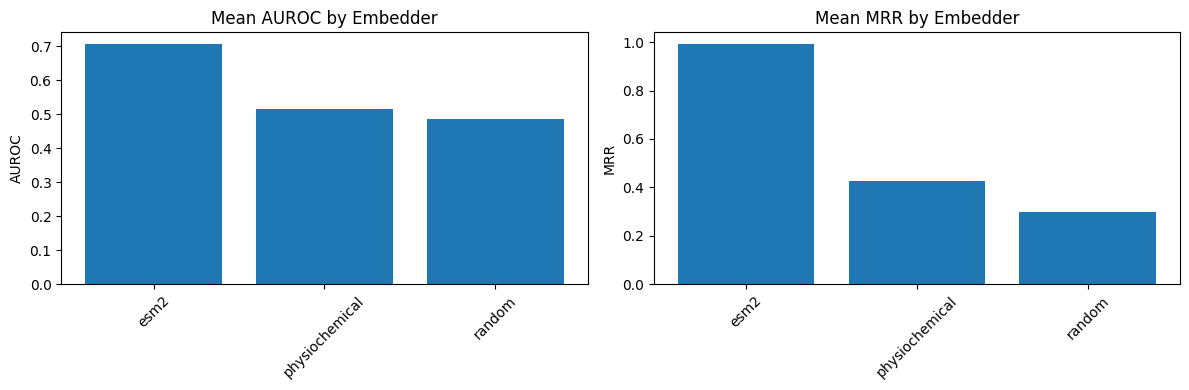

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# AUROC
axes[0].bar(df["embedder"], df["mean_auroc"])
axes[0].set_title("Mean AUROC by Embedder")
axes[0].set_ylabel("AUROC")
axes[0].tick_params(axis='x', rotation=45)

# MRR
axes[1].bar(df["embedder"], df["mean_mrr"])
axes[1].set_title("Mean MRR by Embedder")
axes[1].set_ylabel("MRR")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

ESM-2 substantially outperforms both baselines on MRR (0.991 vs 0.426 vs 0.299), confirming that learned representations consistently rank functionally related proteins at the top of the retrieved set. AUROC differences are smaller because ESM-2's highly homogeneous retrieval neighborhoods reduce the number of queries eligible for scoring — 438 of 500 queries had all-positive top-10 results, leaving only 62 mixed queries for AUROC computation. Physicochemical and random embedders perform near chance level on both metrics, indicating that bulk sequence composition and uninformed baselines are insufficient for functional similarity retrieval.